# GO2 Separating Input – Active Fault Diagnosis with immrax

This notebook demonstrates **active fault diagnosis** for the Unitree Go2 quadruped robot
using **reachable-set-based separating inputs** computed via the `immrax` library.

## Idea

Instead of passively waiting for faults to manifest, we *design* a control input that
makes the reachable sets of different fault scenarios **as disjoint as possible** in
position space. Once we apply the input, measuring where the robot ends up tells us
which fault (if any) is present.

## Three Fault Scenarios

| Scenario | What changes | Parameter |
|---|---|---|
| **Nominal** | Nothing | α = 1 (full yaw authority) |
| **Actuator Fault** | Reduced yaw-rate authority | α ∈ [0.6, 0.8] |
| **Sensor Fault** | vy sensor returns 0 + noise | vy_noise ∈ [−ε, +ε] |

## immrax toolchain

- **`irx.System`** — base class for continuous-time dynamics
- **`irx.natemb(sys)`** — wraps a system with its natural (interval) embedding
- **`irx.Interval`** — axis-aligned interval; a registered JAX pytree
- **`irx.i2ut / irx.ut2i`** — convert between Interval and stacked lower/upper arrays
- **`irx.icentpert`** — create an Interval from a center + half-width
- **`jax.lax.fori_loop`** — JIT-compatible fixed-iteration loop for Euler propagation

## 0. Imports

In [ ]:
# Source - https://stackoverflow.com/a/5399339
# Posted by pv., modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-26, License - CC BY-SA 4.0

%load_ext autoreload
%autoreload 2


In [2]:
import sys
from pathlib import Path

import jax
import jax.numpy as jnp
import immrax as irx
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle

# ── Ensure this notebook's directory (examples/go2/) is importable ────────
_HERE = Path().resolve()   # examples/go2/ when run from notebook directory
for _p in [str(_HERE), str(_HERE.parent)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

# ── Import the immrax-based separating-input module ───────────────────────
from go2_separating_input_immrax import (
    Go2NomActSystem,
    Go2SensorFaultSystem,
    Scenario,
    create_scenarios,
    euler_step,
    propagate_scenario,
    propagate_scenario_multistep,
    position_interval,
    separation_loss,
    separation_loss_multistep,
    SeparatingInputOptimizer,
    optimize_multistart,
    optimize_multistep,
    optimize_multistep_gpu,
    optimize_parallel_gpu,
    MultistepSequenceOptimizer
)

print(f"JAX version : {jax.__version__}")
print(f"immrax      : {irx.__version__ if hasattr(irx, '__version__') else 'loaded'}")
print("✓ Imports OK")
from faulty_car.interval_functions import overlap_size_lax


JAX version : 0.4.34
immrax      : loaded
✓ Imports OK


## 1. System Definitions

The Go2 is modelled as a **unicycle** with three states `x = [px, py, θ]`
and three control inputs `u = [vx, vy, ω]`.

### Nominal / Actuator-Fault dynamics

$$\dot{p}_x = v_x \cos\theta - v_y \sin\theta$$
$$\dot{p}_y = v_x \sin\theta + v_y \cos\theta$$
$$\dot{\theta} = \alpha\,\omega$$

The scalar parameter $\alpha$ is the actuator effectiveness:
- Nominal: $\alpha = 1$
- Actuator fault: $\alpha \in [0.6, 0.8]$ (20–40 % reduced yaw authority)

### Sensor-Fault dynamics (dead-reckoned estimate)

The robot's odometry integrates the *measured* velocity rather than the true one.
When the lateral-velocity sensor returns $v_{y,\text{meas}} \approx 0 + \text{noise}$:

$$\dot{\hat{p}}_x = v_x \cos\hat{\theta} - v_{y,\text{noise}} \sin\hat{\theta}$$
$$\dot{\hat{p}}_y = v_x \sin\hat{\theta} + v_{y,\text{noise}} \cos\hat{\theta}$$
$$\dot{\hat{\theta}} = \omega$$

Here $v_{y,\text{noise}} \in [-\varepsilon, +\varepsilon]$ is an uncertain sensor offset.

In [3]:
# Instantiate both system classes to inspect them
nom_act_sys = Go2NomActSystem()
sf_sys      = Go2SensorFaultSystem()

print("Go2NomActSystem")
print(f"  evolution : {nom_act_sys.evolution}")
print(f"  state dim : {nom_act_sys.xlen}")

print()
print("Go2SensorFaultSystem")
print(f"  evolution : {sf_sys.evolution}")
print(f"  state dim : {sf_sys.xlen}")

# Quick sanity check: evaluate f at a concrete point
t0   = jnp.zeros(())          # MUST be a JAX scalar (not a Python float)
x0   = jnp.array([0.0, 0.0, 0.0])
u0   = jnp.array([1.0, 0.0, 0.5])
p_nom = jnp.array([1.0])      # α = 1 (nominal)

dx = nom_act_sys.f(t0, x0, u0, p_nom)
print()
print(f"Nominal f at x=0, u=[1,0,0.5], α=1:")
print(f"  ṗx = {float(dx[0]):.3f}  ṗy = {float(dx[1]):.3f}  θ̇ = {float(dx[2]):.3f}")

Go2NomActSystem
  evolution : continuous
  state dim : 3

Go2SensorFaultSystem
  evolution : continuous
  state dim : 3

Nominal f at x=0, u=[1,0,0.5], α=1:
  ṗx = 1.000  ṗy = 0.000  θ̇ = 0.500


## 2. Natural Embedding and Interval Propagation

`irx.natemb(sys)` wraps a system so that calling `emb.f(t, x_ut, u, p_ivl)` returns
the **under/over-approximation** of the true derivative for an interval-valued input.

`irx.i2ut(ivl)` packs `[lower, upper]` into a single flat array;  
`irx.ut2i(arr)` unpacks it back into an `irx.Interval`.

In [4]:
# Create the natural embedding for the nominal system
emb = irx.natemb(nom_act_sys)

# Small initial interval (±5 cm in position, ±0.02 rad in heading)
x0_ivl = irx.Interval(
    lower=jnp.array([-0.05, -0.05, -0.02]),
    upper=jnp.array([ 0.05,  0.05,  0.02]),
)
p_ivl = irx.icentpert(jnp.array([1.0]), jnp.zeros(1))   # α = 1 exactly
u_test = jnp.array([0.5, 0.0, 0.3])

# One Euler step (dt = 0.5 s)
from go2_separating_input_immrax import euler_step
x1_ivl = euler_step(emb, x0_ivl, u_test, p_ivl, dt=0.5)

print("One Euler step (dt = 0.5 s, u = [0.5, 0, 0.3], α = 1)")
print(f"  px ∈ [{float(x1_ivl.lower[0]):+.4f}, {float(x1_ivl.upper[0]):+.4f}] m")
print(f"  py ∈ [{float(x1_ivl.lower[1]):+.4f}, {float(x1_ivl.upper[1]):+.4f}] m")
print(f"  θ  ∈ [{float(x1_ivl.lower[2]):+.4f}, {float(x1_ivl.upper[2]):+.4f}] rad")

One Euler step (dt = 0.5 s, u = [0.5, 0, 0.3], α = 1)
  px ∈ [+0.2000, +0.3000] m
  py ∈ [-0.0550, +0.0550] m
  θ  ∈ [+0.1300, +0.1700] rad


## 3. Fault Scenarios

In [5]:
# Default parameters: actuator α ∈ [0.60, 0.80], sensor noise ε = 0.05 m/s
scenarios = create_scenarios(
    actuator_alpha_lo=0.60,
    actuator_alpha_hi=0.80,
    sensor_noise_bound=0.05,
)

print(f"{len(scenarios)} fault scenarios:\n")
for s in scenarios:
    lo = np.array(s.p_interval.lower)
    hi = np.array(s.p_interval.upper)
    print(f"  {s.name}")
    print(f"    p ∈ {lo.tolist()} … {hi.tolist()}")
    print(f"    embedding: {type(s.emb_system).__name__}")
    print()

3 fault scenarios:

  Nominal
    p ∈ [1.0, 1.0] … [1.0, 1.0]
    embedding: TransformEmbedding

  Actuator Fault
    p ∈ [0.6000000238418579, 0.6000000238418579] … [0.800000011920929, 0.800000011920929]
    embedding: TransformEmbedding

  Sensor Fault
    p ∈ [-0.05000000074505806] … [0.05000000074505806]
    embedding: TransformEmbedding



## 4. Initial State and Propagation Horizon

In [6]:
# Initial state uncertainty (small box around the origin)
x0_ivl = irx.Interval(
    lower=jnp.array([-0.05, -0.05, -0.02]),
    upper=jnp.array([ 0.05,  0.05,  0.02]),
)

dt        = 0.1   # Euler step size (s)
num_steps = 10    # total horizon = 5 s

print("Initial state interval:")
print(f"  px ∈ [{float(x0_ivl.lower[0]):+.3f}, {float(x0_ivl.upper[0]):+.3f}] m")
print(f"  py ∈ [{float(x0_ivl.lower[1]):+.3f}, {float(x0_ivl.upper[1]):+.3f}] m")
print(f"  θ  ∈ [{float(x0_ivl.lower[2]):+.3f}, {float(x0_ivl.upper[2]):+.3f}] rad")
print()
print(f"Propagation: {num_steps} × {dt} s = {num_steps * dt:.1f} s total")
print("Separation objective: position space (px, py)")

Initial state interval:
  px ∈ [-0.050, +0.050] m
  py ∈ [-0.050, +0.050] m
  θ  ∈ [-0.020, +0.020] rad

Propagation: 10 × 0.1 s = 1.0 s total
Separation objective: position space (px, py)


## 5. Loss Function

The **separation loss** is the sum of pairwise position-interval overlaps
across all scenario pairs.  Minimising it pushes the reachable sets apart.

$$\mathcal{L}(u) = \sum_{i < j} \text{overlap}\bigl(\Pi_{xy}\, R_i(u),\; \Pi_{xy}\, R_j(u)\bigr)$$

where $R_i(u)$ is the reachable set of scenario $i$ under input $u$ and
$\Pi_{xy}$ projects onto the $(p_x, p_y)$ plane.

Because `irx.Interval` is a JAX pytree and the loop uses `jax.lax.fori_loop`,
`jax.grad` differentiates through the entire propagation automatically.

In [7]:
# Evaluate the loss for two candidate inputs
u_forward  = jnp.array([0.5,  0.0, 0.0])
u_with_turn = jnp.array([0.5, 0.0, 0.3])

loss_fwd  = separation_loss(u_forward,   x0_ivl, scenarios, dt, num_steps)
loss_turn = separation_loss(u_with_turn, x0_ivl, scenarios, dt, num_steps)

print(f"Loss (forward only,  u=[0.5, 0, 0.0]): {float(loss_fwd):.6f} m²")
print(f"Loss (forward+turn,  u=[0.5, 0, 0.3]): {float(loss_turn):.6f} m²")

# Gradient w.r.t. u at the forward-only input.
# scenarios is a list of Python dataclasses (not JAX arrays), so we cannot
# pass it as a traced argument to jax.jit.  Use functools.partial to close
# over all non-differentiable args so that only u is traced.
from functools import partial
_loss_fixed = partial(separation_loss,
                      x0_ivl=x0_ivl, scenarios=scenarios,
                      dt=dt, num_steps=num_steps)
grad_fn = jax.jit(jax.grad(_loss_fixed))
g = grad_fn(u_forward)
print()
print(f"Gradient ∂L/∂u at u_forward: [{float(g[0]):+.4f}, {float(g[1]):+.4f}, {float(g[2]):+.4f}]")
print("(Descent direction: negative gradient → increase turn rate and lateral velocity)")

Loss (forward only,  u=[0.5, 0, 0.0]): 0.036036 m²
Loss (forward+turn,  u=[0.5, 0, 0.3]): 0.034150 m²

Gradient ∂L/∂u at u_forward: [+0.0121, +0.0000, +0.0000]
(Descent direction: negative gradient → increase turn rate and lateral velocity)


## 6. Optimization

`SeparatingInputOptimizer` is created **once** — its `__init__` runs `jax.jit` on
the loss and gradient functions, triggering compilation on the first call.
Passing the same optimizer object into `optimize_multistart` means subsequent
restarts (and any future re-runs) reuse the already-compiled kernels.

In [8]:
import time
dt = 0.2
# Build the optimizer once — JIT compilation of loss_fn and grad_fn happens here.
opt = SeparatingInputOptimizer(scenarios, x0_ivl, dt, num_steps)

num_restarts_gpu = 100
print("Running GPU-parallel multi-start optimization …\n")

_t0 = time.perf_counter()
u_opt, loss_opt, u_final, losses = optimize_parallel_gpu(
    opt,
    num_restarts=num_restarts_gpu,
    learning_rate=1,
    num_iters=150,
)
_t1 = time.perf_counter()

# Reconstruct stats so downstream plotting code can stay unchanged.
stats = opt.evaluate(u_opt)
stats["optimization_time_s"] = _t1 - _t0
stats["num_restarts"] = num_restarts_gpu
stats["all_restart_losses"] = np.array(losses)
stats["best_restart_idx"] = int(jnp.argmin(losses))

print("=" * 60)
print("DONE")
print("=" * 60)
print(f"Optimization time: {_t1 - _t0:.3f} s")
print(f"Best restart:     {stats['best_restart_idx'] + 1}/{num_restarts_gpu}")
print(f"Best loss:        {float(loss_opt):.6f} m²")


Running GPU-parallel multi-start optimization …

DONE
Optimization time: 18.269 s
Best restart:     100/100
Best loss:        0.003229 m²


## 7. Results

In [9]:
print("Optimal separating input:")
print(f"  vx    = {float(u_opt[0]):+.4f} m/s")
print(f"  vy    = {float(u_opt[1]):+.4f} m/s")
print(f"  omega = {float(u_opt[2]):+.4f} rad/s  "
      f"({float(np.degrees(u_opt[2])):+.2f} °/s)")

print(f"\nTotal pairwise overlap: {loss_opt:.6f} m²")

# print("\nPairwise overlaps:")
# for k, v in stats['pairwise_overlaps'].items():
#     print(f"  {k:<45s}: {v:.6f} m²")

# print("\nPosition interval volumes:")
# for k, v in stats['volumes'].items():
#     print(f"  {k:<45s}: {v:.6f} m²")

# print("\nFinal output intervals (what an observer would measure):")
# for s, iv in zip(scenarios, stats['position_intervals']):
#     wx = float(iv.upper[0] - iv.lower[0])
#     wy = float(iv.upper[1] - iv.lower[1])
#     print(f"  {s.name}:")
#     print(f"    px ∈ [{float(iv.lower[0]):+.4f}, {float(iv.upper[0]):+.4f}] m  (width {wx:.4f})")
#     print(f"    py ∈ [{float(iv.lower[1]):+.4f}, {float(iv.upper[1]):+.4f}] m  (width {wy:.4f})")

Optimal separating input:
  vx    = -0.0003 m/s
  vy    = +0.6000 m/s
  omega = -0.3225 rad/s  (-18.48 °/s)

Total pairwise overlap: 0.003229 m²


## 8. Visualise Reachable Sets

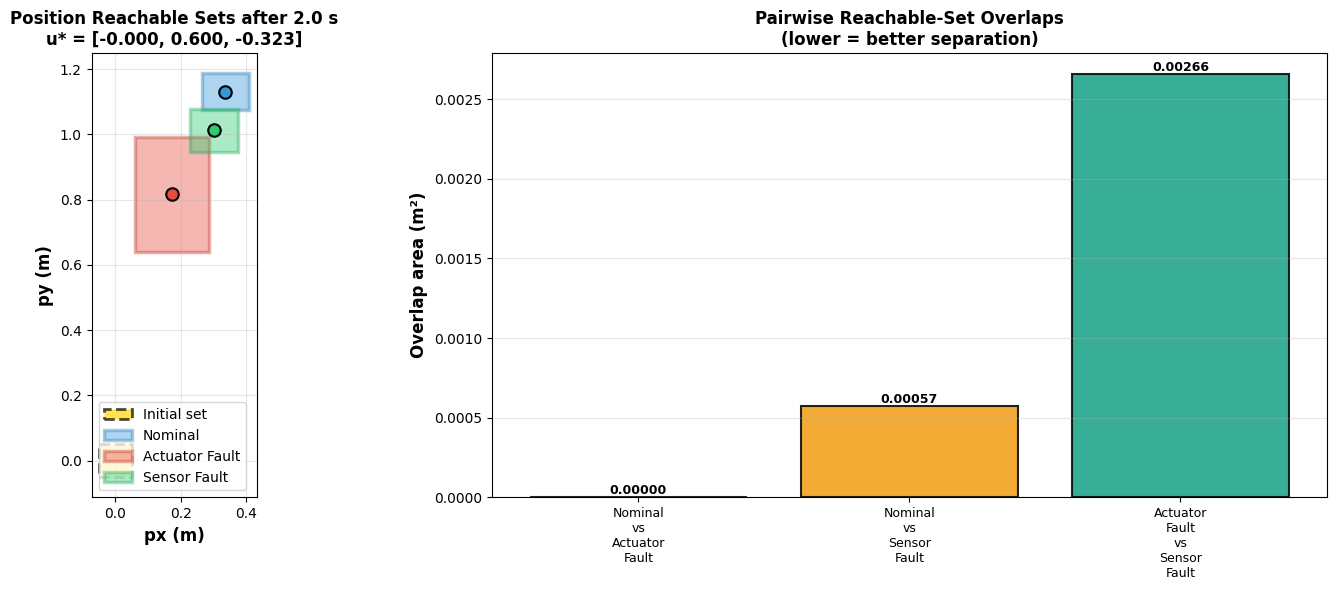

✓ Saved go2_separating_input_immrax_sets.pdf


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors      = ['#3498db', '#e74c3c', '#2ecc71']
edge_colors = ['#2980b9', '#c0392b', '#27ae60']

# ── Left: output reachable sets in (px, py) ──────────────────────────────
ax = axes[0]

# Initial box
ax.add_patch(Rectangle(
    (float(x0_ivl.lower[0]), float(x0_ivl.lower[1])),
    float(x0_ivl.upper[0] - x0_ivl.lower[0]),
    float(x0_ivl.upper[1] - x0_ivl.lower[1]),
    linewidth=2, edgecolor='black', facecolor='gold',
    alpha=0.7, linestyle='--', label='Initial set',
))

for i, (s, iv) in enumerate(zip(scenarios, stats['position_intervals'])):
    w = float(iv.upper[0] - iv.lower[0])
    h = float(iv.upper[1] - iv.lower[1])
    ax.add_patch(Rectangle(
        (float(iv.lower[0]), float(iv.lower[1])), w, h,
        linewidth=2.5, edgecolor=edge_colors[i], facecolor=colors[i],
        alpha=0.40, label=s.name,
    ))
    cx = (float(iv.lower[0]) + float(iv.upper[0])) / 2
    cy = (float(iv.lower[1]) + float(iv.upper[1])) / 2
    ax.plot(cx, cy, 'o', color=colors[i], ms=9,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)

ax.set_xlabel('px (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('py (m)', fontsize=12, fontweight='bold')
ax.set_title(
    f'Position Reachable Sets after {num_steps * dt:.1f} s\n'
    f'u* = [{float(u_opt[0]):.3f}, {float(u_opt[1]):.3f}, {float(u_opt[2]):.3f}]',
    fontsize=12, fontweight='bold',
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.autoscale_view()
ax.set_aspect('equal')

# ── Right: pairwise overlap bar chart ─────────────────────────────────────
ax2 = axes[1]

overlap_labels = list(stats['pairwise_overlaps'].keys())
overlap_values = [float(v) for v in stats['pairwise_overlaps'].values()]
bar_colors = ['#9b59b6', '#f39c12', '#16a085']
short_labels = [
    lbl.replace(' vs ', '\nvs\n').replace(' Fault', '\nFault')
    for lbl in overlap_labels
]

bars = ax2.bar(range(len(overlap_values)), overlap_values,
               color=bar_colors[:len(overlap_values)],
               alpha=0.85, edgecolor='black', linewidth=1.5)

ax2.set_xticks(range(len(overlap_labels)))
ax2.set_xticklabels(short_labels, fontsize=9)
ax2.set_ylabel('Overlap area (m²)', fontsize=12, fontweight='bold')
ax2.set_title('Pairwise Reachable-Set Overlaps\n(lower = better separation)',
              fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, overlap_values):
    ax2.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
             f'{val:.5f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('go2_separating_input_immrax_sets.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved go2_separating_input_immrax_sets.pdf")

## 9. Interval History Along the Horizon

Run the propagation step-by-step and record the interval at each time step
to see how the three scenarios diverge over time.

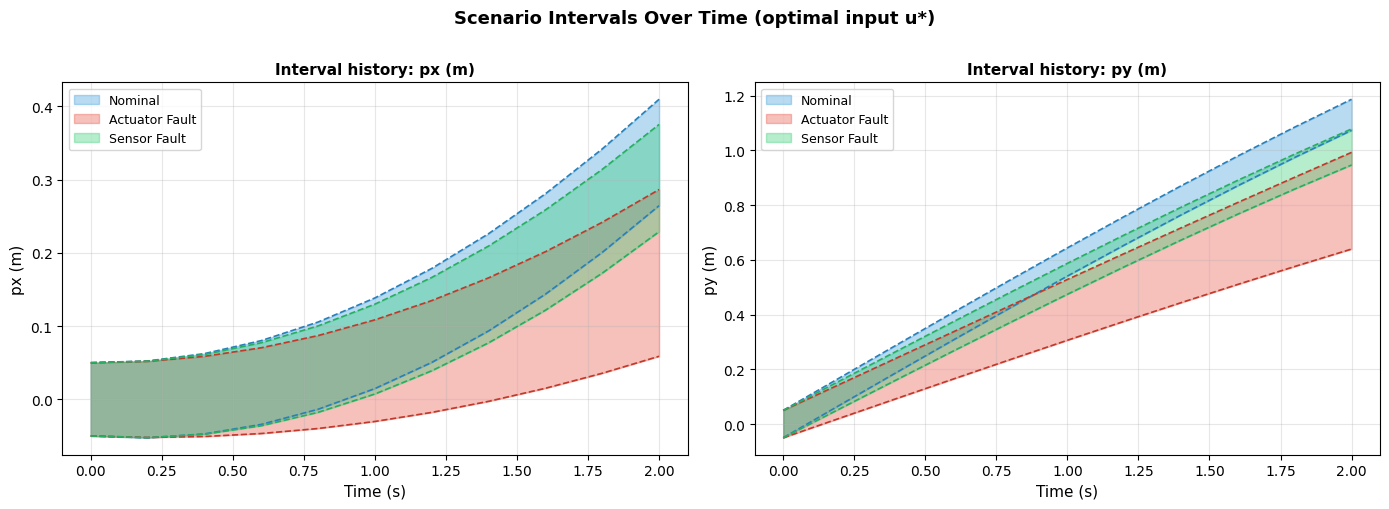

✓ Saved go2_separating_input_immrax_history.pdf


In [11]:
def collect_history(scenario, x0_ivl, u, dt, num_steps):
    """Propagate step-by-step and return list of position intervals."""
    from go2_separating_input_immrax import euler_step, position_interval
    x_ivl = x0_ivl
    history = [position_interval(x_ivl)]
    for _ in range(num_steps):
        x_ivl = euler_step(scenario.emb_system, x_ivl, u, scenario.p_interval, dt)
        history.append(position_interval(x_ivl))
    return history


histories = [collect_history(s, x0_ivl, u_opt, dt, num_steps) for s in scenarios]
times = np.arange(num_steps + 1) * dt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for dim, (ax, label) in enumerate(zip(axes, ['px (m)', 'py (m)'])):
    for i, (s, hist) in enumerate(zip(scenarios, histories)):
        lowers = [float(iv.lower[dim]) for iv in hist]
        uppers = [float(iv.upper[dim]) for iv in hist]
        ax.fill_between(times, lowers, uppers,
                        color=colors[i], alpha=0.35, label=s.name)
        ax.plot(times, lowers, color=edge_colors[i], lw=1.2, ls='--')
        ax.plot(times, uppers, color=edge_colors[i], lw=1.2, ls='--')
    ax.set_xlabel('Time (s)', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'Interval history: {label}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Scenario Intervals Over Time (optimal input u*)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('go2_separating_input_immrax_history.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved go2_separating_input_immrax_history.pdf")

## 10. Compare Candidate Inputs

In [12]:
# Reuse the same optimizer object built in Section 6 (no recompilation).
candidates = [
    ("Optimal u*",          u_opt),
    ("Forward only",        jnp.array([0.5, 0.0, 0.0])),
    ("Forward + turn",      jnp.array([0.5, 0.0, 0.3])),
    ("Circle (no lateral)", jnp.array([0.4, 0.0, 0.5])),
]

print(f"{'Input':<28} {'vx':>6} {'vy':>6} {'ω':>6}  {'Loss (m²)':>12}")
print("-" * 65)
results = []
for name, u in candidates:
    loss = float(opt.loss_fn(u))
    results.append((name, u, loss))
    print(f"{name:<28} {float(u[0]):>6.3f} {float(u[1]):>6.3f} {float(u[2]):>6.3f}  {loss:>12.6f}")

Input                            vx     vy      ω     Loss (m²)
-----------------------------------------------------------------
Optimal u*                   -0.000  0.600 -0.323      0.003229
Forward only                  0.500  0.000  0.000      0.042083
Forward + turn                0.500  0.000  0.300      0.032366
Circle (no lateral)           0.400  0.000  0.500      0.027304


/tmp/ipykernel_6544/1210970154.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=12, ha='right')


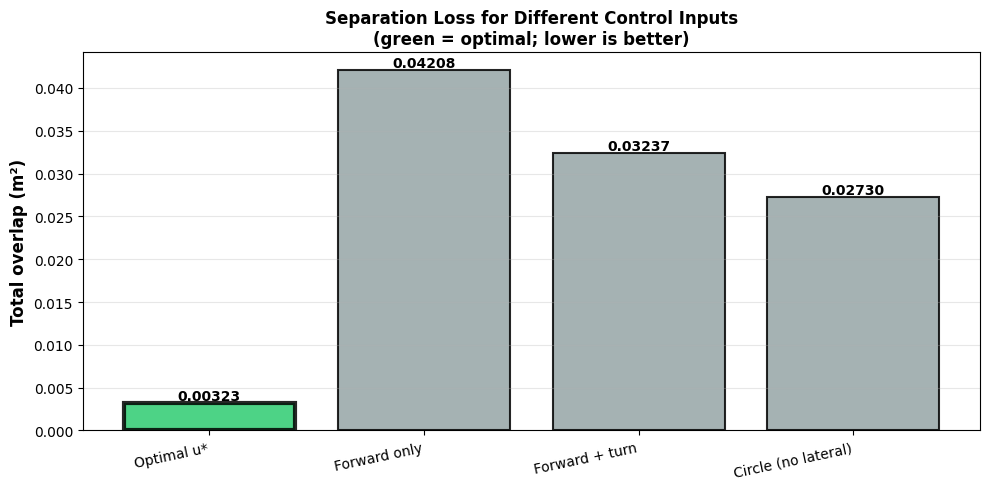

✓ Saved go2_separating_input_immrax_comparison.pdf


In [13]:
names  = [r[0] for r in results]
losses = [r[2] for r in results]

bar_c = ['#2ecc71'] + ['#95a5a6'] * (len(results) - 1)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, losses, color=bar_c, alpha=0.85,
              edgecolor='black', linewidth=1.5)
bars[0].set_linewidth(3)

for bar, val in zip(bars, losses):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
            f'{val:.5f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Total overlap (m²)', fontsize=12, fontweight='bold')
ax.set_title('Separation Loss for Different Control Inputs\n'
             '(green = optimal; lower is better)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(names, rotation=12, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('go2_separating_input_immrax_comparison.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved go2_separating_input_immrax_comparison.pdf")

## 11. Fault Diagnosis: Set Membership Test

After applying the optimal input to the *real* robot and recording its
dead-reckoned position, check which reachable set contains the measurement.

In [14]:
def in_interval(point: np.ndarray, ivl: irx.Interval) -> bool:
    """True if point lies inside the 2-D position interval."""
    return bool(
        np.all(point >= np.array(ivl.lower)) and
        np.all(point <= np.array(ivl.upper))
    )


def diagnose(measured_pos: np.ndarray,
             scenarios,
             pos_intervals) -> None:
    """Print which scenarios are consistent with the measured position."""
    print(f"Measured position: px={measured_pos[0]:+.3f} m, py={measured_pos[1]:+.3f} m")
    print()
    consistent = []
    for s, iv in zip(scenarios, pos_intervals):
        inside = in_interval(measured_pos, iv)
        sym = "✓" if inside else "✗"
        print(f"  {sym}  {s.name}")
        if inside:
            consistent.append(s.name)
    print()
    if len(consistent) == 0:
        print("  → No scenario matches (measurement outside all sets — check model).")
    elif len(consistent) == 1:
        print(f"  → Diagnosis: {consistent[0]}")
    else:
        print(f"  → Ambiguous: consistent with {consistent}")


pos_ivls = stats['position_intervals']

# Simulate three hypothetical measurements, one from each scenario
for s, iv in zip(scenarios, pos_ivls):
    centre = np.array([(float(iv.lower[0]) + float(iv.upper[0])) / 2,
                       (float(iv.lower[1]) + float(iv.upper[1])) / 2])
    print("=" * 50)
    print(f"Simulated measurement from '{s.name}' centre:")
    diagnose(centre, scenarios, pos_ivls)
    print()

Simulated measurement from 'Nominal' centre:
Measured position: px=+0.337 m, py=+1.130 m

  ✓  Nominal
  ✗  Actuator Fault
  ✗  Sensor Fault

  → Diagnosis: Nominal

Simulated measurement from 'Actuator Fault' centre:
Measured position: px=+0.173 m, py=+0.816 m

  ✗  Nominal
  ✓  Actuator Fault
  ✗  Sensor Fault

  → Diagnosis: Actuator Fault

Simulated measurement from 'Sensor Fault' centre:
Measured position: px=+0.302 m, py=+1.013 m

  ✗  Nominal
  ✗  Actuator Fault
  ✓  Sensor Fault

  → Diagnosis: Sensor Fault



## 12. Summary

### What we did

1. Defined unicycle dynamics for three fault modes using `irx.System`.
2. Wrapped each system with `irx.natemb()` to obtain a natural interval embedding.
3. Propagated initial uncertainty through the dynamics using `jax.lax.fori_loop`
   (JIT-compilable, no Python-level unrolling).
4. Built a `separation_loss` that sums pairwise position-interval overlaps.
5. Differentiated through the entire propagation with `jax.grad` and minimised
   with multi-start gradient descent.
6. Used the resulting optimal input for set-membership fault diagnosis.

### Fault-scenario intuition

| Scenario | Signature in (px, py) |
|---|---|
| **Nominal** | Small set; robot follows the commanded trajectory accurately |
| **Actuator Fault** | Larger set; reduced yaw rate creates a different arc |
| **Sensor Fault** | Displaced set; odometry integrates ≈ 0 for vy → drifts laterally |

### Why immrax helps

- `irx.natemb` provides a tight (natural) interval extension — no hand-derived
  Jacobian monotonicity analysis needed.
- `irx.Interval` is a JAX pytree, so it flows through `lax.fori_loop` and
  `jax.grad` without extra boilerplate.
- The same code runs on CPU and GPU/TPU via `JAX_PLATFORMS`.

### Limitations & extensions

- Assumes a **constant** control input over the horizon; a sequence of inputs
  would give more separation power.
- Fault parameter ranges (`α`, `ε`) must be known a priori.
- Only position is used for separation; adding heading (θ) could help for
  scenarios that differ mainly in orientation.

## 13. Multistep Separating Input

Instead of a single constant control input, `optimize_multistep` searches over a
**sequence** of `num_segments` inputs `[u_0, u_1, …, u_{K-1}]`.  Each input `u_k`
is held for `steps_per_segment` Euler steps before switching to the next.

$$\mathbf{u}^* = \arg\min_{\mathbf{u} \in \mathbb{R}^{K \times 3}}
  \sum_{i < j} \text{overlap}\!\bigl(\Pi_{xy}\,R_i(\mathbf{u}),\;\Pi_{xy}\,R_j(\mathbf{u})\bigr)$$

The total horizon is `num_segments × steps_per_segment × dt` seconds.

Advantages over the single-input case:
- Richer manoeuvres can separate scenarios that lie along the same direction
- The gradient flows back through the full sequence via `lax.scan`
- Same `separation_loss_multistep` function is directly JIT-able and differentiable

In [15]:
import time

# ── Parameters ────────────────────────────────────────────────────────────
num_segments      = 2    # number of distinct control inputs in the sequence
steps_per_segment = 5    # Euler steps each control is held (total = 5×2×0.5 = 5 s)
dt = .2
num_restarts_ms   = 100  # multistart batch size for GPU-parallel sequence optimization

print(f"Multistep horizon: {num_segments} segments × {steps_per_segment} steps × {dt} s"
      f" = {num_segments * steps_per_segment * dt:.1f} s total")
print(f"GPU multistart restarts: {num_restarts_ms}\n")

ms_opt = MultistepSequenceOptimizer(
    scenarios=scenarios,
    x0_ivl=x0_ivl,
    dt=dt,
    steps_per_segment=steps_per_segment,
    num_segments=num_segments,
)



Multistep horizon: 2 segments × 5 steps × 0.2 s = 2.0 s total
GPU multistart restarts: 100



In [16]:
from go2_separating_input_immrax import optimize_multistep_gpu_rejit
optimize_multistep_gpu_rejitted = jax.jit(
    partial(
        optimize_multistep_gpu_rejit,
        scenarios=scenarios,
        dt=dt,
        steps_per_segment=steps_per_segment,
        num_segments=num_segments,
        num_restarts=num_restarts_ms,
        learning_rate=1,
        seed=42,
    )
)

In [19]:
_,_,_,_=optimize_multistep_gpu_rejitted(x0_ivl=x0_ivl)

In [ ]:
u_seq_opt,_,_,_=optimize_multistep_gpu_rejitted(x0_ivl=x0_ivl)

In [21]:
print(u_seq_opt)

[[0.37348324 0.43612486 0.6       ]
 [0.57114136 0.5666547  0.25606838]]


In [17]:

_t0 = time.perf_counter()
u_seq_opt, loss_ms, _, all_losses_ms = optimize_multistep_gpu(
    opt=ms_opt,
    num_restarts=num_restarts_ms,
    learning_rate=1,
    num_iters=300,
    seed=42,
)
_t1 = time.perf_counter()

# Build stats dict to keep downstream plotting/evaluation cells unchanged.
pos_ivls = [
    position_interval(
        propagate_scenario_multistep(x0_ivl, u_seq_opt, s, dt, steps_per_segment)
    )
    for s in scenarios
]

n = len(scenarios)
overlaps = {}
for i in range(n):
    for j in range(i + 1, n):
        key_ij = f"{scenarios[i].name} vs {scenarios[j].name}"
        overlaps[key_ij] = float(overlap_size_lax(pos_ivls[i], pos_ivls[j]))

volumes = {
    s.name: float(jnp.prod(iv.upper - iv.lower))
    for s, iv in zip(scenarios, pos_ivls)
}

best_restart_idx = int(jnp.argmin(all_losses_ms))
stats_ms = {
    'position_intervals': pos_ivls,
    'pairwise_overlaps': overlaps,
    'volumes': volumes,
    'optimization_time_s': _t1 - _t0,
    'best_restart_idx': best_restart_idx,
    'all_restart_losses': np.array(all_losses_ms),
    'num_restarts': num_restarts_ms,
}

print(f"\n{'='*60}")
print(f"Multistep optimization time: {_t1 - _t0:.3f} s")
print(f"Final overlap loss:          {float(loss_ms):.6f} m²")
print(f"Best restart index:          {best_restart_idx + 1}/{num_restarts_ms}")
print(f"\nOptimal control sequence  (shape {u_seq_opt.shape}):")
print(f"  {'Seg':>4}  {'vx':>8}  {'vy':>8}  {'ω':>8}")
for k, u_k in enumerate(u_seq_opt):
    print(f"  {k:>4}  {float(u_k[0]):>+8.4f}  {float(u_k[1]):>+8.4f}  {float(u_k[2]):>+8.4f}")


Multistep optimization time: 25.817 s
Final overlap loss:          0.000000 m²
Best restart index:          1/100

Optimal control sequence  (shape (2, 3)):
   Seg        vx        vy         ω
     0   +0.3735   +0.4361   +0.6000
     1   +0.5711   +0.5667   +0.2561


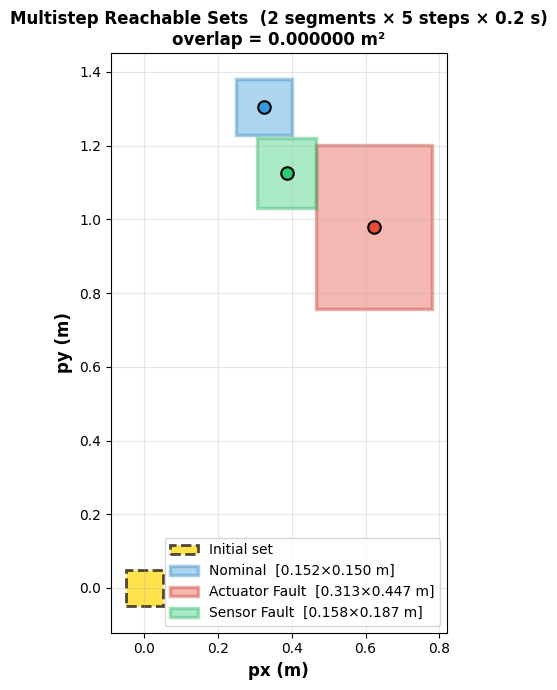

✓ Saved go2_separating_input_multistep.pdf


In [18]:
# ── Visualise final reachable sets ────────────────────────────────────────
colors      = ['#3498db', '#e74c3c', '#2ecc71']
edge_colors = ['#2980b9', '#c0392b', '#27ae60']

fig, ax = plt.subplots(figsize=(8, 7))

ax.add_patch(Rectangle(
    (float(x0_ivl.lower[0]), float(x0_ivl.lower[1])),
    float(x0_ivl.upper[0] - x0_ivl.lower[0]),
    float(x0_ivl.upper[1] - x0_ivl.lower[1]),
    linewidth=2, edgecolor='black', facecolor='gold',
    alpha=0.7, linestyle='--', label='Initial set',
))

for i, (s, iv) in enumerate(zip(scenarios, stats_ms['position_intervals'])):
    w = float(iv.upper[0] - iv.lower[0])
    h = float(iv.upper[1] - iv.lower[1])
    ax.add_patch(Rectangle(
        (float(iv.lower[0]), float(iv.lower[1])), w, h,
        linewidth=2.5, edgecolor=edge_colors[i], facecolor=colors[i],
        alpha=0.40, label=f"{s.name}  [{w:.3f}×{h:.3f} m]",
    ))
    cx = (float(iv.lower[0]) + float(iv.upper[0])) / 2
    cy = (float(iv.lower[1]) + float(iv.upper[1])) / 2
    ax.plot(cx, cy, 'o', color=colors[i], ms=9,
            markeredgecolor='black', markeredgewidth=1.5, zorder=10)

ax.set_xlabel('px (m)', fontsize=12, fontweight='bold')
ax.set_ylabel('py (m)', fontsize=12, fontweight='bold')
ax.set_title(
    f'Multistep Reachable Sets  ({num_segments} segments × {steps_per_segment} steps × {dt} s)\n'
    f'overlap = {loss_ms:.6f} m²',
    fontsize=12, fontweight='bold',
)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.autoscale_view()
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('go2_separating_input_multistep.pdf', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved go2_separating_input_multistep.pdf")